# NuggetKriging on the noisy Branin 2D function (Julia)

This notebook demonstrates `NuggetKriging`, which estimates a **global nugget**
effect (homoscedastic noise variance) from the data. Unlike `NoiseKriging`
where noise variances are known and provided per point, here the nugget is
a single scalar that is optimised alongside the other hyperparameters.

Steps:
1. Setup jlibkriging
2. Define the Branin function and add noise
3. Build a space-filling design and evaluate it
4. Fit a `NuggetKriging` model
5. Predict on a fine grid and plot mean + uncertainty
6. Inspect model parameters (including the estimated nugget)

## 0. Setup

Build the C++ core and install the Julia binding (skip if already done).
Requires: `cmake`, a C++ compiler, Julia ≥ 1.10.

```shell
julia -e 'using Pkg; Pkg.develop(path="bindings/Julia/jlibkriging")'
```

In [1]:
using jlibkriging
using Plots
using Random

println("jlibkriging loaded")

jlibkriging loaded


## 1. Noisy Branin function

Same as the `NoiseKriging` example: the Branin function on $[0,1]^2$
with additive Gaussian noise ($\sigma_{\varepsilon} = 5$).

The difference is that here we **do not tell** the model the noise level.
Instead, `NuggetKriging` will estimate a single global nugget from the data.

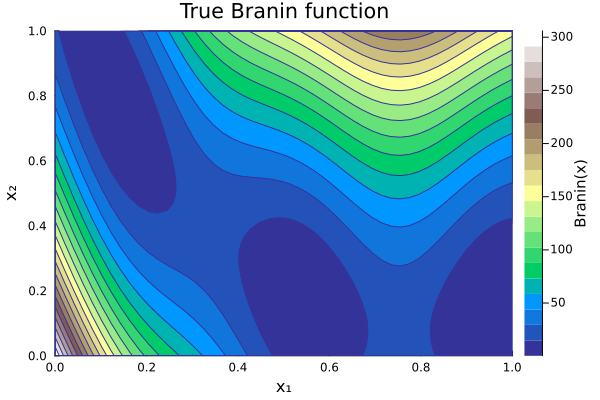

In [2]:
function branin(X::Matrix{Float64})
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    return (x2 .- 5 ./ (4π^2) .* x1.^2 .+ 5 ./ π .* x1 .- 6).^2 .+
           10 .* (1 - 1 / (8π)) .* cos.(x1) .+ 10
end

# 50×50 evaluation grid
grid_x = range(0, 1, length=50)
G1 = [x1 for x2 in grid_x, x1 in grid_x]
G2 = [x2 for x2 in grid_x, x1 in grid_x]
grid_pts = hcat(vec(G1), vec(G2))
z_true = reshape(branin(grid_pts), 50, 50)

contourf(collect(grid_x), collect(grid_x), z_true,
         levels=20, color=:terrain, xlabel="x₁", ylabel="x₂",
         title="True Branin function", colorbar_title="Branin(x)")

## 2. Design of experiments (with noise)

We sample $n = 40$ points using a Latin Hypercube Design and add
Gaussian noise with $\sigma_{\varepsilon} = 5$.

Unlike `NoiseKriging`, we do **not** pass noise variances — the model
estimates a single nugget parameter.

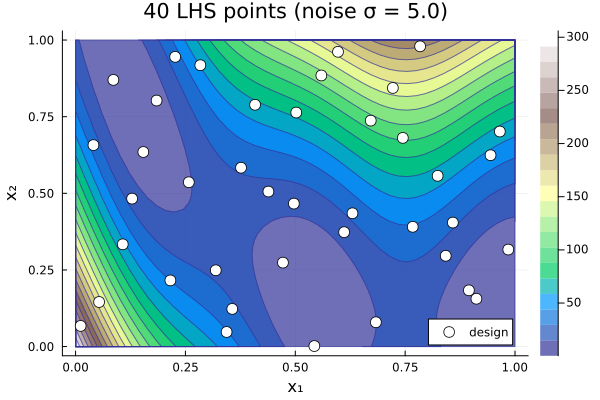

In [3]:
Random.seed!(42)

function lhs(n::Int, d::Int)
    X = zeros(n, d)
    for j in 1:d
        perm = randperm(n)
        X[:, j] = (perm .- rand(n)) ./ n
    end
    return X
end

n = 40
noise_sd = 5.0
X = lhs(n, 2)
y_true = branin(X)
y = y_true .+ noise_sd .* randn(n)

p = contourf(collect(grid_x), collect(grid_x), z_true,
             levels=20, color=:terrain, alpha=0.7,
             xlabel="x₁", ylabel="x₂",
             title="$n LHS points (noise σ = $noise_sd)")
scatter!(p, X[:, 1], X[:, 2],
         mc=:white, msc=:black, ms=6, label="design")

## 3. Fit a NuggetKriging model

`NuggetKriging()` has the same interface as `Kriging()` (no `noise` argument).
It automatically estimates the nugget effect during fitting.

In [4]:
k = NuggetKriging(y, X, "matern5_2"; optim="BFGS10")
println(jlibkriging.summary(k))

* data: 40x[0.0115761,0.984721],[0.00178984,0.979547] -> 40x[-6.40369,250.104]
* trend constant (est.): 304.114
* variance (est.): 128503
* covariance:
  * kernel: matern5_2
  * range (est.): 0.676086, 2.07892
  * nugget (est.): 14.3021
  * fit:
    * objective: LL
    * optim: BFGS10



## 4. Predict on a fine grid

`predict()` returns a named tuple with fields `mean`, `stdev`.
The mean is a smooth estimate of the underlying function.

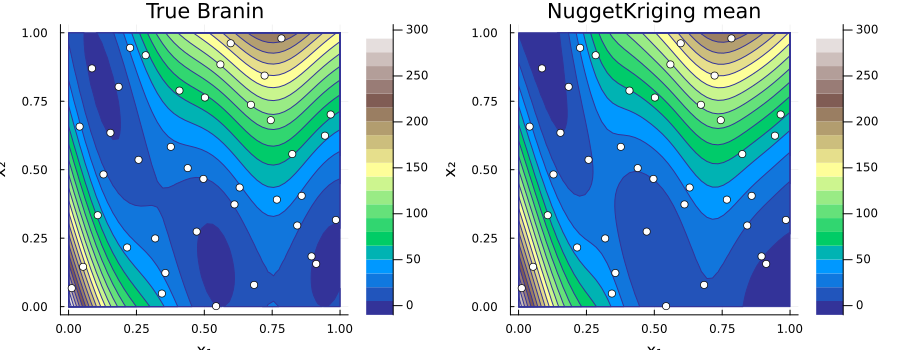

In [5]:
pred   = predict(k, grid_pts; return_stdev=true)
z_mean = reshape(pred.mean,  50, 50)
z_sd   = reshape(pred.stdev, 50, 50)

vmin = min(minimum(z_true), minimum(z_mean))
vmax = max(maximum(z_true), maximum(z_mean))

p1 = contourf(collect(grid_x), collect(grid_x), z_true,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="True Branin", xlabel="x₁", ylabel="x₂")
scatter!(p1, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

p2 = contourf(collect(grid_x), collect(grid_x), z_mean,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="NuggetKriging mean", xlabel="x₁", ylabel="x₂")
scatter!(p2, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

plot(p1, p2, layout=(1, 2), size=(900, 350))

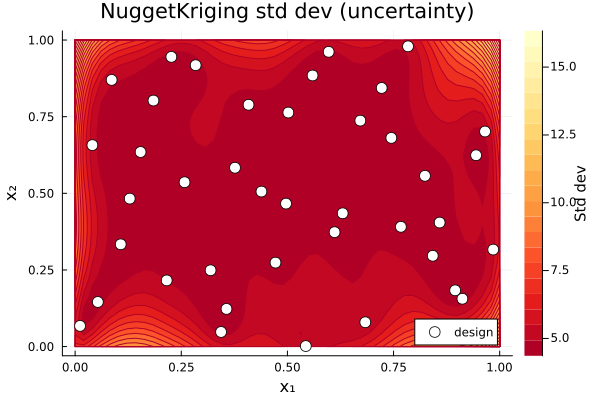

In [6]:
# Posterior standard deviation (uncertainty)
p = contourf(collect(grid_x), collect(grid_x), z_sd,
             levels=20, color=cgrad(:YlOrRd, rev=true),
             title="NuggetKriging std dev (uncertainty)",
             xlabel="x₁", ylabel="x₂", colorbar_title="Std dev")
scatter!(p, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=6, label="design")

## 5. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$,
**nugget**, and the log-likelihood at the optimum.

Compare the estimated nugget with the true noise variance
$\sigma_{\varepsilon}^2 = 25$.

In [7]:
println("Kernel       : ", kernel(k))
println("Theta (range): ", round.(get_theta(k), digits=4))
println("Sigma2       : ", round(get_sigma2(k), digits=4))
println("Nugget       : ", round(get_nugget(k), digits=4))
println("LogLikelihood: ", round(log_likelihood(k), digits=4))
println()
println("True noise variance: ", noise_sd^2)

Kernel       : matern5_2
Theta (range): 

[0.6761, 2.0789]
Sigma2       : 128503.415
Nugget       : 14.3021
LogLikelihood: -162.1467

True noise variance: 25.0


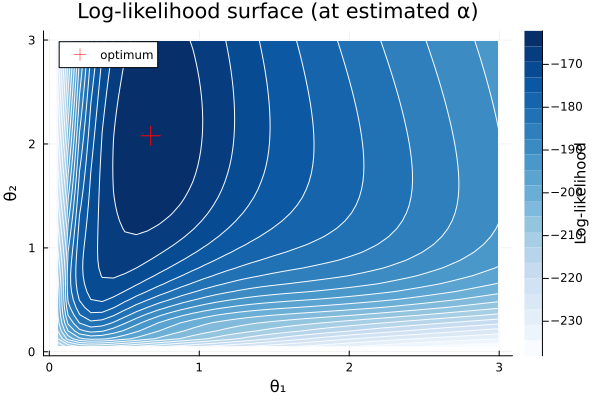

In [8]:
# Log-likelihood surface over (theta1, theta2) at estimated alpha
# NuggetKriging::log_likelihood_fun expects [theta1, theta2, alpha]
# with alpha = sigma2 / (sigma2 + nugget)
s2 = get_sigma2(k)
nug = get_nugget(k)
alpha_hat = s2 / (s2 + nug)
theta_vals = range(0.05, 3.0, length=40)
ll_mat = [log_likelihood_fun(k, [t1, t2, alpha_hat]).ll for t2 in theta_vals, t1 in theta_vals]

p = contourf(collect(theta_vals), collect(theta_vals), ll_mat,
             levels=20, color=:Blues,
             title="Log-likelihood surface (at estimated α)",
             xlabel="θ₁", ylabel="θ₂", colorbar_title="Log-likelihood")
th = get_theta(k)
scatter!(p, [th[1]], [th[2]], marker=:cross, ms=10, mc=:red, msc=:red,
         label="optimum")